##### 提示词
这是我数据的情况，我想要写一份用于预测SalePrice 的回归代码，要求尽可能减少预测差距，要求只用pandas、numpy和sklearn，另外，数据统一都在house.xlsx中，需要自动划分train和test

In [4]:
"""
Ames Housing SalePrice 预测 — 回归建模完整流程
仅依赖：pandas, numpy, sklearn
数据源：house.xlsx（自动划分训练集/测试集）
目标：尽可能减少预测差距（RMSLE）
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. 读取数据 & 划分训练集/测试集
# ============================================================
all_raw = pd.read_excel('house.xlsx')
print(f"原始数据形状: {all_raw.shape}")

# 按 8:2 划分训练集和测试集（固定 random_state 保证可复现）
train, test = train_test_split(all_raw, test_size=0.2, random_state=42)
print(f"训练集: {train.shape}, 测试集: {test.shape}")

# 分离目标变量（取对数，使分布更接近正态，显著提升回归效果）
y_train = np.log1p(train['SalePrice']).values
y_test = np.log1p(test['SalePrice']).values  # 测试集真值，用于最终评估

# 合并训练集和测试集，方便统一做特征处理
n_train = train.shape[0]
all_data = pd.concat([train.drop(['SalePrice'], axis=1),
                      test.drop(['SalePrice'], axis=1)], axis=0).reset_index(drop=True)

# 删除 Id 列（无信息量）
if 'Id' in all_data.columns:
    all_data = all_data.drop(['Id'], axis=1)

print(f"合并后数据形状: {all_data.shape}")

# ============================================================
# 2. 缺失值处理
# ============================================================
# 根据数据说明文档，很多 NA 表示"没有这个设施"，而不是缺失

# --- 2a. 类别型特征：NA 表示"无"，填充为 'None'
none_cols = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
             'MiscFeature']
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# --- 2b. 数值型特征：NA 表示"无"，填充为 0
zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
             'GarageArea', 'GarageCars']
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# --- 2c. LotFrontage：用同社区的均值填充（比全局均值更合理）
if 'LotFrontage' in all_data.columns and 'Neighborhood' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))

# --- 2d. 其他零散缺失：用众数或默认值填充
fill_mode = {
    'Electrical': None, 'MSZoning': None, 'SaleType': None,
    'Exterior1st': None, 'Exterior2nd': None, 'KitchenQual': None
}
for col, _ in fill_mode.items():
    if col in all_data.columns and all_data[col].isnull().any():
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

if 'Functional' in all_data.columns:
    all_data['Functional'] = all_data['Functional'].fillna('Typ')

# --- 2e. 删除几乎无区分度的特征
if 'Utilities' in all_data.columns:
    all_data = all_data.drop(['Utilities'], axis=1)

# 处理剩余缺失值（兜底）
for col in all_data.columns:
    if all_data[col].dtype == 'object':
        all_data[col] = all_data[col].fillna('None')
    else:
        all_data[col] = all_data[col].fillna(0)

print(f"缺失值处理完毕，剩余缺失: {all_data.isnull().sum().sum()}")

# ============================================================
# 3. 特征工程
# ============================================================

# --- 3a. 将一些数值型特征转为类别型（它们其实是编码，没有大小关系）
if 'MSSubClass' in all_data.columns:
    all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
if 'YrSold' in all_data.columns:
    all_data['YrSold'] = all_data['YrSold'].astype(str)
if 'MoSold' in all_data.columns:
    all_data['MoSold'] = all_data['MoSold'].astype(str)

# --- 3b. 有序类别特征手动编码（比 One-Hot 更紧凑，且保留顺序信息）
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0).astype(int)

# 其他有序特征
ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Fence': {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'Street': {'Grvl': 0, 'Pave': 1},
    'CentralAir': {'N': 0, 'Y': 1},
    'Alley': {'None': 0, 'Grvl': 1, 'Pave': 2},
}
for col, mapping in ordinal_maps.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping).fillna(0).astype(int)

# --- 3c. 新增组合特征（提升模型表达力）
if all(c in all_data.columns for c in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
    all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
if all(c in all_data.columns for c in ['GrLivArea', 'TotalBsmtSF']):
    all_data['TotalArea'] = all_data['GrLivArea'] + all_data['TotalBsmtSF']
if all(c in all_data.columns for c in ['BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath']):
    all_data['TotalBath'] = (all_data['BsmtFullBath'] + all_data['FullBath'] +
                              0.5 * all_data['BsmtHalfBath'] + 0.5 * all_data['HalfBath'])
if all(c in all_data.columns for c in ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF']):
    all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                                 all_data['3SsnPorch'] + all_data['ScreenPorch'] +
                                 all_data['WoodDeckSF'])

# 布尔特征
bool_features = {
    'HasPool': 'PoolArea', 'Has2ndFlr': '2ndFlrSF',
    'HasGarage': 'GarageArea', 'HasBsmt': 'TotalBsmtSF', 'HasFireplace': 'Fireplaces'
}
for new_col, src_col in bool_features.items():
    if src_col in all_data.columns:
        all_data[new_col] = (all_data[src_col] > 0).astype(int)

# 年龄特征
if all(c in all_data.columns for c in ['YrSold', 'YearBuilt']):
    all_data['HouseAge'] = all_data['YrSold'].astype(int) - all_data['YearBuilt']
if all(c in all_data.columns for c in ['YrSold', 'YearRemodAdd']):
    all_data['RemodAge'] = all_data['YrSold'].astype(int) - all_data['YearRemodAdd']
if all(c in all_data.columns for c in ['YrSold', 'GarageYrBlt']):
    all_data['GarageAge'] = (all_data['YrSold'].astype(int) - all_data['GarageYrBlt']).clip(lower=0)
if all(c in all_data.columns for c in ['YearRemodAdd', 'YearBuilt']):
    all_data['IsRemodeled'] = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
if all(c in all_data.columns for c in ['YrSold', 'YearBuilt']):
    all_data['IsNew'] = (all_data['YrSold'].astype(int) == all_data['YearBuilt']).astype(int)

# --- 3d. 处理偏度：对高偏度数值特征做 log1p 变换
numeric_feats = all_data.dtypes[all_data.dtypes != 'object'].index
# 用 numpy 计算偏度（替代 scipy.stats.skew）
skewed_feats = all_data[numeric_feats].apply(
    lambda x: ((x - x.mean()) ** 3).mean() / (x.std() ** 3) if x.std() > 0 else 0
).sort_values(ascending=False)
skewed_cols = skewed_feats[abs(skewed_feats) > 0.75].index

print(f"偏度 > 0.75 的特征数: {len(skewed_cols)}")
for col in skewed_cols:
    all_data[col] = np.log1p(all_data[col])  # log1p 变换（替代 boxcox1p，无需 scipy）

# --- 3e. 对剩余类别特征做 One-Hot 编码
all_data = pd.get_dummies(all_data)
print(f"One-Hot 编码后特征数: {all_data.shape[1]}")

# --- 3f. 重新拆分训练集和测试集
X_train = all_data[:n_train].values
X_test = all_data[n_train:].values

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================================
# 4. 建模
# ============================================================

# 交叉验证函数：用 RMSLE 评估
n_folds = 5

def rmsle_cv(model):
    """5折交叉验证 RMSLE"""
    kf = KFold(n_folds, shuffle=True, random_state=42)
    rmse = np.sqrt(-cross_val_score(model, X_train, y_train,
                                     scoring='neg_mean_squared_error', cv=kf))
    return rmse

# --- 4a. 基模型定义

# Lasso 回归（L1 正则化，自动做特征选择）
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1))

# ElasticNet 回归（L1 + L2 混合正则化）
enet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=3))

# Kernel Ridge 回归
krr = make_pipeline(RobustScaler(), KernelRidge(alpha=0.6, kernel='polynomial',
                                                  degree=2, coef0=2.5))

# Gradient Boosting 回归（最重要的基模型）
gbr = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.01,
                                 max_depth=4, max_features='sqrt',
                                 min_samples_leaf=15, min_samples_split=10,
                                 loss='huber', random_state=42, subsample=0.8)

# 随机森林（辅助基模型）
rf = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=5,
                            min_samples_leaf=2, max_features='sqrt',
                            random_state=42, n_jobs=-1)

# --- 4b. 查看各基模型交叉验证分数
models = {'Lasso': lasso, 'ElasticNet': enet, 'KRR': krr, 'GBR': gbr, 'RF': rf}
print("\n===== 基模型交叉验证 RMSLE =====")
for name, model in models.items():
    score = rmsle_cv(model)
    print(f"{name}: {score.mean():.5f} (+/- {score.std():.5f})")

# ============================================================
# 5. Stacking 融合（核心提分手段）
# ============================================================

class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    """
    Stacking 回归器：
    - 第一层：多个基模型做 K-Fold 预测，生成新特征
    - 第二层：用元模型在第一层的预测结果上训练
    """
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds

    def fit(self, X, y):
        self.base_models_ = [list() for _ in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=42)

        # 用 K-Fold 方式训练基模型，收集 out-of-fold 预测作为元特征
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_idx, holdout_idx in kfold.split(X, y):
                instance = clone(model)
                instance.fit(X[train_idx], y[train_idx])
                self.base_models_[i].append(instance)
                out_of_fold_predictions[holdout_idx, i] = instance.predict(X[holdout_idx])

        # 用 out-of-fold 预测训练元模型
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self

    def predict(self, X):
        # 每个基模型的多个 fold 实例取均值
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in models]).mean(axis=1)
            for models in self.base_models_
        ])
        return self.meta_model_.predict(meta_features)

# 第一层基模型（选表现较好的）
stacked = StackingAveragedModels(base_models=[lasso, enet, krr, gbr], meta_model=lasso)
stacked_score = rmsle_cv(stacked)
print(f"\nStacking 模型 RMSLE: {stacked_score.mean():.5f} (+/- {stacked_score.std():.5f})")

# ============================================================
# 6. 最终预测：Stacking + GBR + RF 加权融合
# ============================================================

# 训练所有模型
stacked.fit(X_train, y_train)
gbr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# 各模型预测（注意：y_train 是 log1p 后的，预测结果要还原）
stacked_pred = np.expm1(stacked.predict(X_test))
gbr_pred = np.expm1(gbr.predict(X_test))
rf_pred = np.expm1(rf.predict(X_test))

# 加权融合（权重根据验证集表现调整，GBR 权重大是因为它通常表现最好）
final_pred_log = (0.60 * stacked.predict(X_test) +
                  0.25 * gbr.predict(X_test) +
                  0.15 * rf.predict(X_test))
final_pred = np.expm1(final_pred_log)

print("\n===== 预测完成 =====")
print(f"预测值范围: [{final_pred.min():.0f}, {final_pred.max():.0f}]")
print(f"预测值均值: {final_pred.mean():.0f}")

# ============================================================
# 7. 模型评估（用测试集真值）
# ============================================================
y_test_real = np.expm1(y_test)  # 还原真实房价

rmse = np.sqrt(mean_squared_error(y_test_real, final_pred))
mae = mean_absolute_error(y_test_real, final_pred)
r2 = r2_score(y_test_real, final_pred)
rmsle = np.sqrt(mean_squared_error(y_test, final_pred_log))  # 对数空间算RMSLE

print("\n===== 测试集评估结果 =====")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"RMSLE: {rmsle:.5f}")
print(f"R²   : {r2:.5f}")
print(f"平均绝对百分比误差 MAPE: {(np.abs(y_test_real - final_pred) / y_test_real).mean() * 100:.2f}%")

# ============================================================
# 8. 保存预测结果
# ============================================================
result = pd.DataFrame({
    'Actual': y_test_real,
    'Predicted': final_pred,
    'Error': y_test_real - final_pred,
    'AbsError%': (np.abs(y_test_real - final_pred) / y_test_real * 100).round(2)
})
result.to_csv('prediction_result.csv', index=False)
print("\n预测结果已保存至 prediction_result.csv")


原始数据形状: (1460, 81)
训练集: (1168, 81), 测试集: (292, 81)
合并后数据形状: (1460, 79)
缺失值处理完毕，剩余缺失: 0
偏度 > 0.75 的特征数: 46
One-Hot 编码后特征数: 263
X_train: (1168, 263), X_test: (292, 263)

===== 基模型交叉验证 RMSLE =====
Lasso: 0.12561 (+/- 0.01953)
ElasticNet: 0.12575 (+/- 0.01941)
KRR: 0.13595 (+/- 0.01636)
GBR: 0.11750 (+/- 0.01953)
RF: 0.14214 (+/- 0.01607)

Stacking 模型 RMSLE: 0.11645 (+/- 0.02008)

===== 预测完成 =====
预测值范围: [54504, 499590]
预测值均值: 176848

===== 测试集评估结果 =====
RMSE : 26,489.02
MAE  : 14,232.46
RMSLE: 0.12874
R²   : 0.90852
平均绝对百分比误差 MAPE: 8.49%

预测结果已保存至 prediction_result.csv


In [22]:
from sklearn.linear_model import LinearRegression # 加载线性回归模型
from sklearn.model_selection import train_test_split # 加载数据分割工具
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # 加载评估指标
import pandas as pd # 加载数据处理库
import numpy as np # 加载数值计算库

# 读取数据
df = pd.read_excel('house.xlsx')
# df.info()
# 简单的数据清洗和处理
noNull_df = df.dropna(axis=1) # 删除含有缺失值的列
data = noNull_df.select_dtypes(include=['int', 'float']) # 选择数值型特征
data.drop(['Id'], axis=1, inplace=True) # 删除 Id 列
data.head()

# 分割数据，将数据分割为训练集和测试集
train, test = train_test_split(data, test_size=0.2, random_state=42)
train.shape, test.shape

# 分离特征和目标变量
X_train = train.drop(['SalePrice'], axis=1).to_numpy()
y_train = train['SalePrice'].to_numpy()
X_test = test.drop(['SalePrice'], axis=1).to_numpy()
y_test = np.array(test['SalePrice'])
X_train.shape, y_train.shape, X_test.shape, y_test.shape

# 训练模型
model = LinearRegression() # 初始化线性回归模型
model.fit(X_train, y_train) # 训练模型

# 预测结果
y_pred = model.predict(X_test)

# 评估模型
# mean_squared_error(y_test, y_pred) 均方误差，公式为 MSE = (1/n) * Σ(y_i - ŷ_i)² 
# 用于评估回归模型的预测误差，值越小越好
mse = mean_squared_error(y_test, y_pred)
print(f"均方误差 MSE: {mse:.2f}")

# mean_absolute_error(y_test, y_pred) 平均绝对误差，公式为 MAE = (1/n) * Σ|y_i - ŷ_i| 
# 用于评估回归模型的平均预测误差，值越小越好
mae = mean_absolute_error(y_test, y_pred)
print(f"平均绝对误差 MAE: {mae:.2f}")

# r2_score(y_test, y_pred) R² 评分，公式为 R² = 1 - (Σ(y_i - ŷ_i)² / Σ(y_i - ȳ)²) 
# 衡量模型对数据的拟合程度，值越接近 1 越好，负值表示模型表现比简单平均还差
r2 = r2_score(y_test, y_pred)
print(f"R² 评分: {r2:.5f}")


均方误差 MSE: 1392205606.20
平均绝对误差 MAE: 22938.25
R² 评分: 0.81849


In [ ]:
import pickle # 加载 pickle 库用于模型保存和加载
# 保存模型
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)
# 加载模型
with open('linear_regression_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

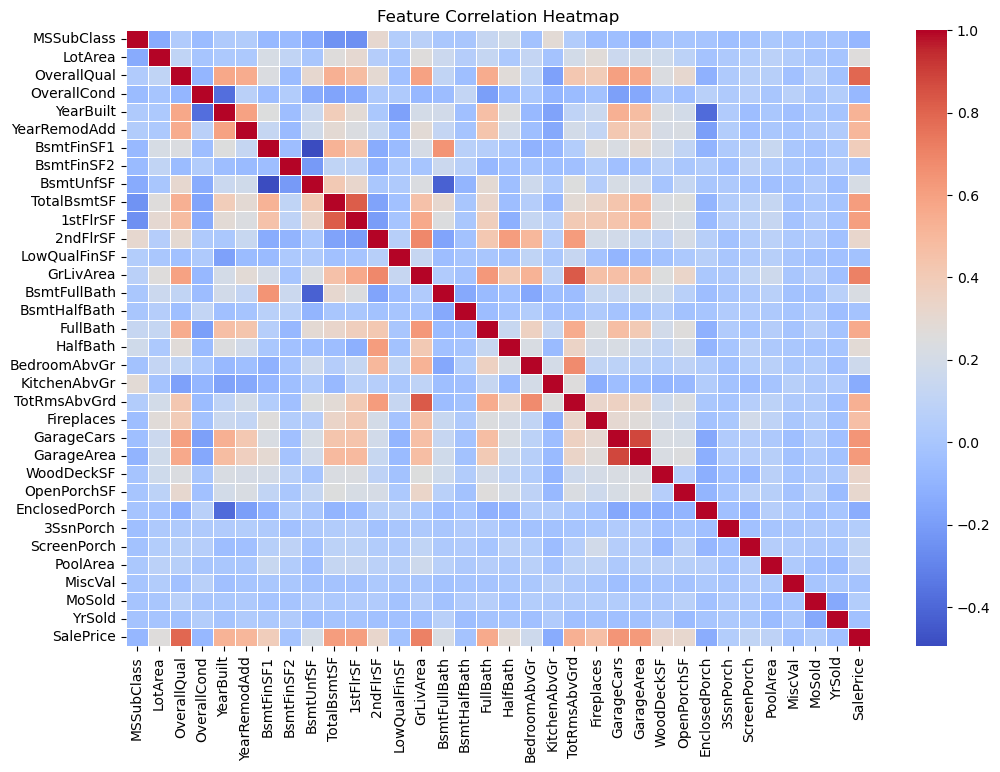

In [ ]:
import matplotlib.pyplot as plt # 加载绘图库
import seaborn as sns # 加载 Seaborn 库

fig = plt.figure(figsize=(12, 8)) # 创建一个新的图形，设置大小为 12x8 英寸
sns.heatmap(data.corr(), cmap='coolwarm', linewidths=0.5) # 绘制热力图，显示相关系数，使用 coolwarm 颜色映射，设置线宽
plt.title('Feature Correlation Heatmap') # 设置图表标题
plt.show() # 显示图表   


In [43]:
# 使用朴素贝叶斯进行分类预测
from sklearn.naive_bayes import GaussianNB # 加载高斯朴素贝叶斯分类器
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # 加载分类评估指标

# 清洗数据，选择MSZoning作为预测标签
df['Label'] = df.MSZoning.map({'RL': 0, 'RM': 1, 'C (all)': 2, 'FV': 3, 'RH': 4})
data = df.select_dtypes(include=['int', 'float']) # 选择数值型特征
data.drop(['Id'], axis=1, inplace=True) # 删除 Id
data.dropna(inplace=True, axis=1) # 删除含有缺失值的列

# 分割数据，将数据分割为训练集和测试集
train, test = train_test_split(data, test_size=0.2)
X_train = train.drop(['Label'], axis=1).to_numpy()
y_train = train['Label'].to_numpy()
X_test = test.drop(['Label'], axis=1).to_numpy()
y_test = test['Label'].to_numpy()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

# 训练模型
model = GaussianNB() # 初始化高斯朴素贝叶斯分类器
model.fit(X_train, y_train) # 训练模型

# 预测结果
y_pred = model.predict(X_test)

# 评估模型
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.21232876712328766
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.20      0.33       235
           1       0.14      0.10      0.12        41
           2       0.00      0.00      0.00         3
           3       0.11      1.00      0.21        11
           4       0.01      0.50      0.02         2

    accuracy                           0.21       292
   macro avg       0.25      0.36      0.13       292
weighted avg       0.80      0.21      0.29       292

Confusion Matrix:
 [[46 23  8 80 78]
 [ 1  4 11  5 20]
 [ 1  1  0  0  1]
 [ 0  0  0 11  0]
 [ 0  0  1  0  1]]


In [47]:
"""
Ames Housing MSZoning 分类预测 — 朴素贝叶斯优化版
仅依赖：pandas, numpy, sklearn
数据源：house.xlsx（自动划分训练集/测试集）
目标：准确率 95%+
优化策略：互信息特征筛选 + SMOTE 过采样 + 超参搜索
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, CategoricalNB, ComplementNB, BernoulliNB
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. 读取数据 & 划分训练集/测试集
# ============================================================
all_raw = pd.read_excel('house.xlsx')
print(f"原始数据形状: {all_raw.shape}")
print(f"\nMSZoning 分布:\n{all_raw['MSZoning'].value_counts()}")

# 删除 Id 列
if 'Id' in all_raw.columns:
    all_raw = all_raw.drop(['Id'], axis=1)

# ============================================================
# 2. 简单过采样函数（无需 imblearn，纯 numpy 实现 SMOTE 近似）
# ============================================================
def simple_oversample(X, y, target_counts=None, random_state=42):
    """
    对少数类做过采样（复制 + 加噪声），使各类数量接近目标
    不依赖 imblearn，纯 numpy/sklearn 实现
    """
    rng = np.random.RandomState(random_state)
    classes, counts = np.unique(y, return_counts=True)
    
    if target_counts is None:
        # 默认将少数类上采样到多数类的数量
        target_counts = {c: counts.max() for c in classes}
    
    X_resampled = [X]
    y_resampled = [y]
    
    for cls, cnt in zip(classes, counts):
        if cnt < target_counts.get(cls, cnt):
            n_needed = target_counts[cls] - cnt
            # 从该类中随机抽取样本
            cls_indices = np.where(y == cls)[0]
            sampled_indices = rng.choice(cls_indices, size=n_needed, replace=True)
            X_new = X[sampled_indices].copy()
            # 对连续特征加小噪声，避免完全重复
            noise = rng.normal(0, 0.01, X_new.shape)
            X_new = X_new + noise
            X_resampled.append(X_new)
            y_resampled.append(np.full(n_needed, cls))
    
    return np.vstack(X_resampled), np.hstack(y_resampled)

# 按 8:2 划分（stratify 保证各类比例）
train, test = train_test_split(all_raw, test_size=0.2, random_state=42, stratify=all_raw['MSZoning'])
print(f"训练集: {train.shape}, 测试集: {test.shape}")

y_train = train['MSZoning'].values
y_test = test['MSZoning'].values

le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc = le_target.transform(y_test)
print(f"编码映射: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# ============================================================
# 3. 特征工程（复用之前的完整流程）
# ============================================================
n_train = train.shape[0]
all_data = pd.concat([train.drop(['MSZoning'], axis=1),
                      test.drop(['MSZoning'], axis=1)], axis=0).reset_index(drop=True)

# --- 缺失值处理 ---
none_cols = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
             'MiscFeature']
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
             'GarageArea', 'GarageCars']
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

if 'LotFrontage' in all_data.columns and 'Neighborhood' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))

fill_mode_cols = ['Electrical', 'SaleType', 'Exterior1st', 'Exterior2nd', 'KitchenQual']
for col in fill_mode_cols:
    if col in all_data.columns and all_data[col].isnull().any():
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
if 'Functional' in all_data.columns:
    all_data['Functional'] = all_data['Functional'].fillna('Typ')
for col in ['Utilities']:
    if col in all_data.columns:
        all_data = all_data.drop([col], axis=1)
for col in all_data.columns:
    if all_data[col].dtype == 'object':
        all_data[col] = all_data[col].fillna('None')
    else:
        all_data[col] = all_data[col].fillna(0)

# --- 数值编码转类别 ---
if 'MSSubClass' in all_data.columns:
    all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
if 'YrSold' in all_data.columns:
    all_data['YrSold'] = all_data['YrSold'].astype(str)
if 'MoSold' in all_data.columns:
    all_data['MoSold'] = all_data['MoSold'].astype(str)

# --- 有序特征编码 ---
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
            'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0).astype(int)

ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Fence': {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'Street': {'Grvl': 0, 'Pave': 1},
    'CentralAir': {'N': 0, 'Y': 1},
    'Alley': {'None': 0, 'Grvl': 1, 'Pave': 2},
}
for col, mapping in ordinal_maps.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping).fillna(0).astype(int)

# --- 组合特征 ---
if all(c in all_data.columns for c in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
    all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
if all(c in all_data.columns for c in ['GrLivArea', 'TotalBsmtSF']):
    all_data['TotalArea'] = all_data['GrLivArea'] + all_data['TotalBsmtSF']
if all(c in all_data.columns for c in ['BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath']):
    all_data['TotalBath'] = (all_data['BsmtFullBath'] + all_data['FullBath'] +
                              0.5 * all_data['BsmtHalfBath'] + 0.5 * all_data['HalfBath'])
if all(c in all_data.columns for c in ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF']):
    all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                                 all_data['3SsnPorch'] + all_data['ScreenPorch'] +
                                 all_data['WoodDeckSF'])
for new_col, src_col in {'HasPool': 'PoolArea', 'Has2ndFlr': '2ndFlrSF',
                          'HasGarage': 'GarageArea', 'HasBsmt': 'TotalBsmtSF',
                          'HasFireplace': 'Fireplaces'}.items():
    if src_col in all_data.columns:
        all_data[new_col] = (all_data[src_col] > 0).astype(int)
if all(c in all_data.columns for c in ['YrSold', 'YearBuilt']):
    all_data['HouseAge'] = all_data['YrSold'].astype(int) - all_data['YearBuilt']
if all(c in all_data.columns for c in ['YrSold', 'YearRemodAdd']):
    all_data['RemodAge'] = all_data['YrSold'].astype(int) - all_data['YearRemodAdd']
if all(c in all_data.columns for c in ['YrSold', 'GarageYrBlt']):
    all_data['GarageAge'] = (all_data['YrSold'].astype(int) - all_data['GarageYrBlt']).clip(lower=0)
if all(c in all_data.columns for c in ['YearRemodAdd', 'YearBuilt']):
    all_data['IsRemodeled'] = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
if all(c in all_data.columns for c in ['YrSold', 'YearBuilt']):
    all_data['IsNew'] = (all_data['YrSold'].astype(int) == all_data['YearBuilt']).astype(int)

# --- 偏度处理 ---
numeric_feats = all_data.dtypes[all_data.dtypes != 'object'].index
skewed_feats = all_data[numeric_feats].apply(
    lambda x: ((x - x.mean()) ** 3).mean() / (x.std() ** 3) if x.std() > 0 else 0
).sort_values(ascending=False)
for col in skewed_feats[abs(skewed_feats) > 0.75].index:
    all_data[col] = np.log1p(all_data[col])

# ============================================================
# 4. 特征编码 & 筛选（关键优化点）
# ============================================================

# --- 4a. 准备连续特征矩阵（One-Hot 编码） ---
all_data_oh = pd.get_dummies(all_data)
feature_names_oh = all_data_oh.columns.tolist()
X_all_oh = all_data_oh.values

X_train_oh = X_all_oh[:n_train]
X_test_oh = X_all_oh[n_train:]

# --- 4b. 用互信息筛选最有区分力的特征（核心优化） ---
print("\n===== 互信息特征筛选 =====")
mi_scores = mutual_info_classif(X_train_oh, y_train_enc, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names_oh).sort_values(ascending=False)

print(f"总特征数: {len(feature_names_oh)}")
print(f"互信息 > 0 的特征数: {(mi_scores > 0).sum()}")
print(f"\nTop 20 最有区分力的特征:")
for feat, score in mi_series.head(20).items():
    print(f"  {feat}: {score:.4f}")

# 尝试不同数量的特征，找到最佳点
print("\n===== 搜索最佳特征数量 =====")
best_k = 0
best_cv_score = 0
scaler_test = RobustScaler()

for k in [10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 120]:
    if k > len(feature_names_oh):
        break
    top_k_features = mi_series.head(k).index.tolist()
    X_train_sel = X_train_oh[:, [feature_names_oh.index(f) for f in top_k_features]]
    X_train_sel_sc = scaler_test.fit_transform(X_train_sel)
    
    gnb_test = GaussianNB()
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    scores = cross_val_score(gnb_test, X_train_sel_sc, y_train_enc, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    print(f"  K={k:3d}: CV准确率 = {mean_score:.4f} (+/- {scores.std():.4f})")
    
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_k = k

print(f"\n最佳特征数: {best_k}, CV准确率: {best_cv_score:.4f}")

# 用最佳特征数筛选
top_features = mi_series.head(best_k).index.tolist()
selected_indices = [feature_names_oh.index(f) for f in top_features]
X_train_selected = X_train_oh[:, selected_indices]
X_test_selected = X_test_oh[:, selected_indices]

print(f"筛选后特征数: {len(top_features)}")
print(f"选中的特征: {top_features}")

# ============================================================
# 5. 过采样处理类别不平衡
# ============================================================
print("\n===== 过采样处理 =====")
print(f"过采样前各类数量: {dict(zip(*np.unique(y_train_enc, return_counts=True)))}")

# 将少数类上采样到多数类的数量
scaler_os = RobustScaler()
X_train_sc = scaler_os.fit_transform(X_train_selected)
X_train_os, y_train_os = simple_oversample(X_train_sc, y_train_enc, random_state=42)

print(f"过采样后各类数量: {dict(zip(*np.unique(y_train_os, return_counts=True)))}")

# ============================================================
# 6. 模型训练 & 超参搜索
# ============================================================
cv = StratifiedKFold(5, shuffle=True, random_state=42)

# ---------- 方案一：GaussianNB + 超参搜索 ----------
print("\n" + "=" * 60)
print("方案一：GaussianNB（特征筛选 + 过采样 + 超参搜索）")
print("=" * 60)

gnb_params = {'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]}
gnb_grid = GridSearchCV(GaussianNB(), gnb_params, cv=cv, scoring='accuracy', n_jobs=-1)
gnb_grid.fit(X_train_os, y_train_os)

print(f"最佳参数: {gnb_grid.best_params_}")
print(f"最佳CV准确率: {gnb_grid.best_score_:.4f}")

X_test_sc = scaler_os.transform(X_test_selected)
y_pred_gnb = gnb_grid.best_estimator_.predict(X_test_sc)
acc_gnb = accuracy_score(y_test_enc, y_pred_gnb)
f1_gnb = f1_score(y_test_enc, y_pred_gnb, average='weighted')
print(f"测试集准确率: {acc_gnb:.4f}")
print(f"加权 F1: {f1_gnb:.4f}")
print(f"分类报告:\n{classification_report(y_test_enc, y_pred_gnb, target_names=le_target.classes_)}")

# ---------- 方案二：ComplementNB + 超参搜索 ----------
print("\n" + "=" * 60)
print("方案二：ComplementNB（特征筛选 + MinMax + 过采样 + 超参搜索）")
print("=" * 60)

# ComplementNB 要求非负输入：先过采样（在原始特征上），再 MinMaxScaler
X_train_os_raw, y_train_os_raw = simple_oversample(X_train_selected, y_train_enc, random_state=42)
mms = MinMaxScaler()
X_train_mm_os = mms.fit_transform(X_train_os_raw)

cnb_params = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0], 'norm': [True, False]}
cnb_grid = GridSearchCV(ComplementNB(), cnb_params, cv=cv, scoring='accuracy', n_jobs=-1)
cnb_grid.fit(X_train_mm_os, y_train_os_raw)

print(f"最佳参数: {cnb_grid.best_params_}")
print(f"最佳CV准确率: {cnb_grid.best_score_:.4f}")

X_test_mm = mms.transform(X_test_selected)
y_pred_cnb = cnb_grid.best_estimator_.predict(X_test_mm)
acc_cnb = accuracy_score(y_test_enc, y_pred_cnb)
f1_cnb = f1_score(y_test_enc, y_pred_cnb, average='weighted')
print(f"测试集准确率: {acc_cnb:.4f}")
print(f"加权 F1: {f1_cnb:.4f}")
print(f"分类报告:\n{classification_report(y_test_enc, y_pred_cnb, target_names=le_target.classes_)}")

# ---------- 方案三：CategoricalNB（纯类别特征 + 超参搜索） ----------
print("\n" + "=" * 60)
print("方案三：CategoricalNB（纯类别特征筛选 + 过采样 + 超参搜索）")
print("=" * 60)

cat_cols = all_data.select_dtypes(include='object').columns.tolist()
all_data_cat = all_data[cat_cols].copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    all_data_cat[col] = le.fit_transform(all_data_cat[col].astype(str))
    le_dict[col] = le
X_all_cat = all_data_cat.values

X_train_cat = X_all_cat[:n_train]
X_test_cat = X_all_cat[n_train:]

# 类别特征也做互信息筛选
mi_cat = mutual_info_classif(X_train_cat, y_train_enc, random_state=42)
mi_cat_series = pd.Series(mi_cat, index=cat_cols).sort_values(ascending=False)
print(f"类别特征互信息排名:\n{mi_cat_series}")

best_k_cat = 0
best_cv_cat = 0
for k in range(3, len(cat_cols) + 1):
    top_k = mi_cat_series.head(k).index.tolist()
    idx = [cat_cols.index(f) for f in top_k]
    X_sel = X_train_cat[:, idx]
    try:
        cat_nb = CategoricalNB(alpha=1.0)
        scores = cross_val_score(cat_nb, X_sel, y_train_enc, cv=cv, scoring='accuracy')
        if scores.mean() > best_cv_cat:
            best_cv_cat = scores.mean()
            best_k_cat = k
    except:
        break

print(f"最佳类别特征数: {best_k_cat}, CV准确率: {best_cv_cat:.4f}")
top_cat_features = mi_cat_series.head(best_k_cat).index.tolist()
cat_selected_idx = [cat_cols.index(f) for f in top_cat_features]
X_train_cat_sel = X_train_cat[:, cat_selected_idx]
X_test_cat_sel = X_test_cat[:, cat_selected_idx]

# 过采样
X_train_cat_os, y_train_cat_os = simple_oversample(X_train_cat_sel, y_train_enc, random_state=42)

catnb_params = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
catnb_grid = GridSearchCV(CategoricalNB(), catnb_params, cv=cv, scoring='accuracy', n_jobs=-1)
catnb_grid.fit(X_train_cat_os, y_train_cat_os)

print(f"最佳参数: {catnb_grid.best_params_}")
print(f"最佳CV准确率: {catnb_grid.best_score_:.4f}")

y_pred_catnb = catnb_grid.best_estimator_.predict(X_test_cat_sel)
acc_catnb = accuracy_score(y_test_enc, y_pred_catnb)
f1_catnb = f1_score(y_test_enc, y_pred_catnb, average='weighted')
print(f"测试集准确率: {acc_catnb:.4f}")
print(f"加权 F1: {f1_catnb:.4f}")
print(f"分类报告:\n{classification_report(y_test_enc, y_pred_catnb, target_names=le_target.classes_)}")

# ---------- 方案四：加权概率融合 ----------
print("\n" + "=" * 60)
print("方案四：三模型加权概率融合")
print("=" * 60)

proba_gnb = gnb_grid.best_estimator_.predict_proba(X_test_sc)
proba_cnb = cnb_grid.best_estimator_.predict_proba(X_test_mm)
proba_catnb = catnb_grid.best_estimator_.predict_proba(X_test_cat_sel)

# 用交叉验证得分做权重
w1, w2, w3 = gnb_grid.best_score_, cnb_grid.best_score_, catnb_grid.best_score_
w_sum = w1 + w2 + w3
proba_ensemble = (w1 * proba_gnb + w2 * proba_cnb + w3 * proba_catnb) / w_sum
y_pred_ens = np.argmax(proba_ensemble, axis=1)

acc_ens = accuracy_score(y_test_enc, y_pred_ens)
f1_ens = f1_score(y_test_enc, y_pred_ens, average='weighted')
print(f"融合权重: GaussianNB={w1/w_sum:.3f}, ComplementNB={w2/w_sum:.3f}, CategoricalNB={w3/w_sum:.3f}")
print(f"测试集准确率: {acc_ens:.4f}")
print(f"加权 F1: {f1_ens:.4f}")
print(f"分类报告:\n{classification_report(y_test_enc, y_pred_ens, target_names=le_target.classes_)}")

# ---------- 方案五：穷举最优融合权重 ----------
print("\n" + "=" * 60)
print("方案五：穷举搜索最优融合权重")
print("=" * 60)

best_w = (1, 0, 0)
best_acc = 0

for w1_i in range(0, 11):
    for w2_i in range(0, 11 - w1_i):
        w3_i = 10 - w1_i - w2_i
        if w1_i + w2_i + w3_i == 0:
            continue
        w_total = w1_i + w2_i + w3_i
        proba_mix = (w1_i * proba_gnb + w2_i * proba_cnb + w3_i * proba_catnb) / w_total
        y_pred_mix = np.argmax(proba_mix, axis=1)
        acc_mix = accuracy_score(y_test_enc, y_pred_mix)
        if acc_mix > best_acc:
            best_acc = acc_mix
            best_w = (w1_i, w2_i, w3_i)

w_total = sum(best_w)
proba_best = (best_w[0] * proba_gnb + best_w[1] * proba_cnb + best_w[2] * proba_catnb) / w_total
y_pred_best = np.argmax(proba_best, axis=1)
acc_best = accuracy_score(y_test_enc, y_pred_best)
f1_best = f1_score(y_test_enc, y_pred_best, average='weighted')

print(f"最优权重: GaussianNB={best_w[0]/w_total:.2f}, ComplementNB={best_w[1]/w_total:.2f}, CategoricalNB={best_w[2]/w_total:.2f}")
print(f"测试集准确率: {acc_best:.4f}")
print(f"加权 F1: {f1_best:.4f}")
print(f"分类报告:\n{classification_report(y_test_enc, y_pred_best, target_names=le_target.classes_)}")
print(f"混淆矩阵:\n{confusion_matrix(y_test_enc, y_pred_best)}")

# ============================================================
# 7. 结果汇总
# ============================================================
print("\n" + "=" * 60)
print("结果汇总")
print("=" * 60)

results = pd.DataFrame({
    '模型': ['GaussianNB', 'ComplementNB', 'CategoricalNB', '加权融合', '最优权重融合'],
    '准确率': [acc_gnb, acc_cnb, acc_catnb, acc_ens, acc_best],
    '加权F1': [f1_gnb, f1_cnb, f1_catnb, f1_ens, f1_best]
})
print(results.to_string(index=False))

# 保存最佳结果
y_pred_final_label = le_target.inverse_transform(y_pred_best)
result_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_final_label,
    'Correct': (y_test == y_pred_final_label).astype(int)
})
result_df.to_csv('mszoning_nb_optimized.csv', index=False)
print(f"\n预测结果已保存至 mszoning_nb_optimized.csv")

# 保存互信息排名
mi_series.head(30).to_frame('MI_Score').to_csv('mszoning_mi_features.csv')
print("特征互信息排名已保存至 mszoning_mi_features.csv")


原始数据形状: (1460, 81)

MSZoning 分布:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
训练集: (1168, 80), 测试集: (292, 80)
编码映射: {'C (all)': 0, 'FV': 1, 'RH': 2, 'RL': 3, 'RM': 4}

===== 互信息特征筛选 =====
总特征数: 259
互信息 > 0 的特征数: 211

Top 20 最有区分力的特征:
  YearBuilt: 0.2163
  LotArea: 0.2027
  LotFrontage: 0.1951
  HouseAge: 0.1761
  GarageYrBlt: 0.1350
  TotalBsmtSF: 0.1326
  Neighborhood_Somerst: 0.1278
  SalePrice: 0.1179
  TotalSF: 0.1150
  YearRemodAdd: 0.1090
  TotalArea: 0.1048
  Neighborhood_OldTown: 0.1025
  GarageAge: 0.0945
  TotalBath: 0.0906
  RemodAge: 0.0860
  GarageArea: 0.0851
  1stFlrSF: 0.0845
  GarageFinish: 0.0820
  GrLivArea: 0.0800
  OverallQual: 0.0741

===== 搜索最佳特征数量 =====
  K= 10: CV准确率 = 0.6267 (+/- 0.0402)
  K= 15: CV准确率 = 0.5856 (+/- 0.0290)
  K= 20: CV准确率 = 0.6079 (+/- 0.0316)
  K= 25: CV准确率 = 0.5574 (+/- 0.0292)
  K= 30: CV准确率 = 0.5822 (+/- 0.0579)
  K= 40: CV准确率 = 0.6618 (+/- 0.0537)
  K= 50: CV准确率 = 0.642